In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv('D:\\Projetos\\AB test analysis\\Fast Food Marketing Campaign AB Test\\WA_Marketing-Campaign-Ajustado.csv')

def plot_sales_boxplots(df):
    """
    Gera boxplots de SalesInThousands para cada promoção para identificar outliers.
    """
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Promotion', y='SalesInThousands', hue='Promotion', palette='viridis', legend=False)
    plt.title('Boxplot de SalesInThousands por Promotion')
    plt.ylabel('SalesInThousands')
    plt.show()

def calculate_lift(df, control_promotion=1):
    """
    Calcula o lift de SalesInThousands entre as promoções, assumindo uma promoção de controle.
    
    Retorna um dicionário com os lifts percentuais para cada promoção vs controle.
    """
    means = df.groupby('Promotion')['SalesInThousands'].mean()
    control_mean = means[control_promotion]
    lifts = {}
    for promo in means.index:
        if promo != control_promotion:
            lift = (means[promo] - control_mean) / control_mean * 100
            lifts[f'Promotion {promo} vs {control_promotion}'] = lift
    return lifts

def promotion_anova_tukey(df, metric='SalesInThousands', group_col='Promotion'):
    """
    Realiza ANOVA seguida de teste post-hoc de Tukey para avaliar qual promoção tem melhor média
    de SalesInThousands.
    """
    groups = [df[df[group_col] == g][metric].values for g in sorted(df[group_col].unique())]
    f_stat, p_value = stats.f_oneway(*groups)

    tukey = pairwise_tukeyhsd(endog=df[metric], groups=df[group_col].astype(str), alpha=0.05)
    tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])

    means = df.groupby(group_col)[metric].mean().sort_values(ascending=False)
    best = means.index[0]

    comparisons = []
    for row in tukey_df.itertuples(index=False):
        group1, group2, meandiff, p_adj, lower, upper, reject = row
        if str(best) == str(group1) or str(best) == str(group2):
            comparisons.append({
                'group1': group1,
                'group2': group2,
                'meandiff': meandiff,
                'p_adj': p_adj,
                'reject': reject,
                'lower': lower,
                'upper': upper
            })

    better_than_all = all(
        (row['reject'] and ((str(best) == str(row['group1']) and row['meandiff'] > 0) or (str(best) == str(row['group2']) and row['meandiff'] < 0)))
        for row in comparisons
    ) if len(comparisons) > 0 else False

    return {
        'anova': {'f_stat': f_stat, 'p_value': p_value},
        'tukey_df': tukey_df,
        'means': means,
        'best_promotion': best,
        'best_significant_vs_others': better_than_all,
        'comparisons_with_best': pd.DataFrame(comparisons)
    }


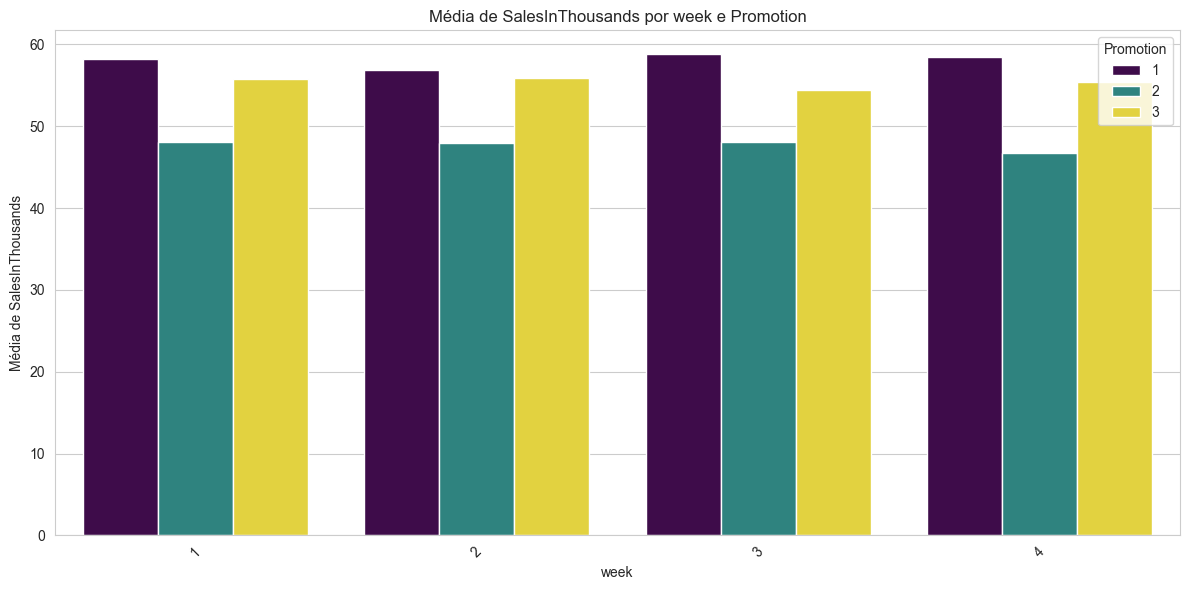

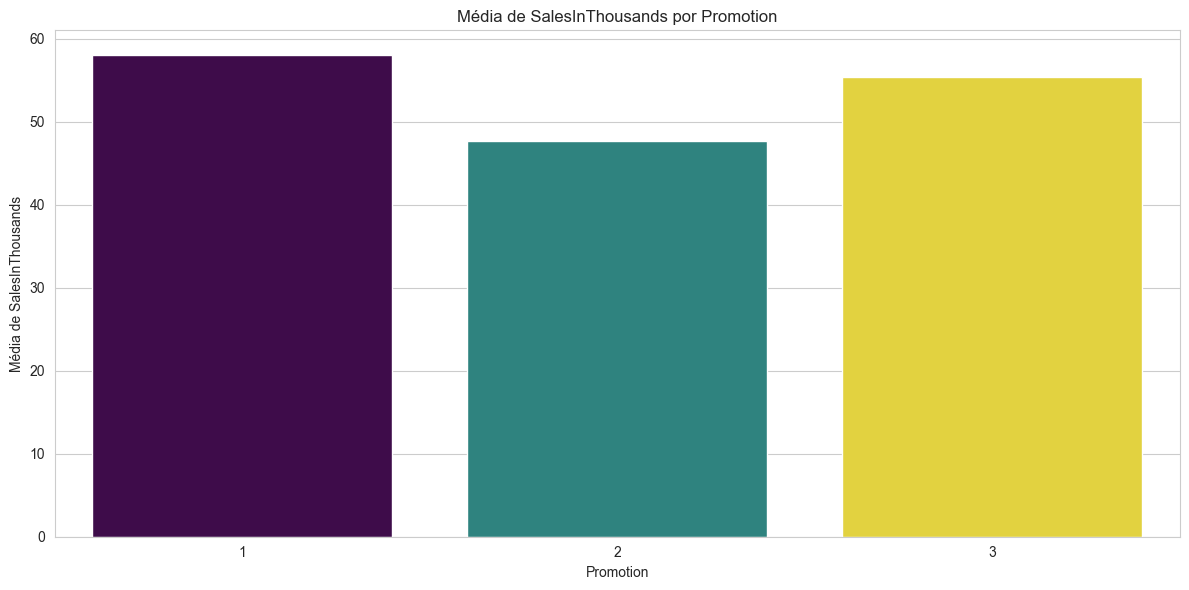

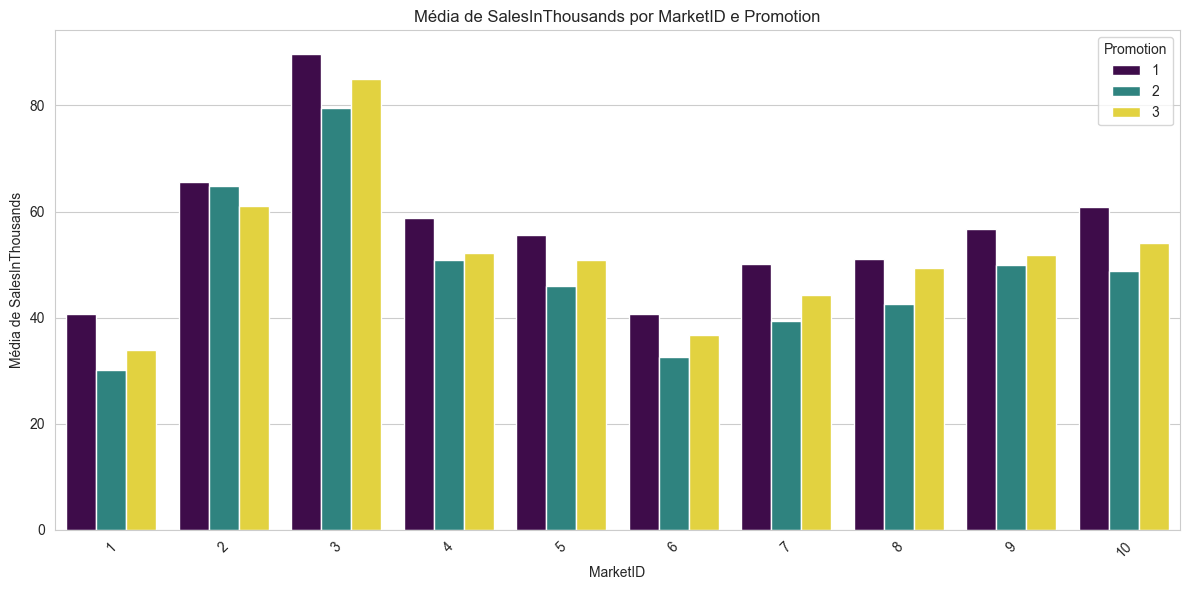

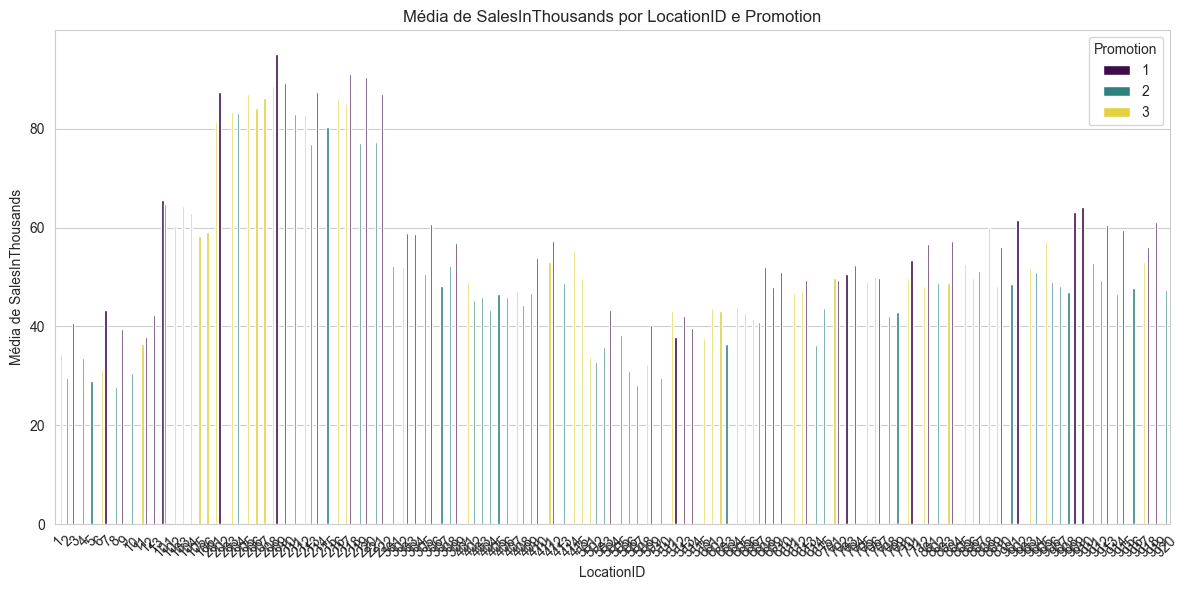

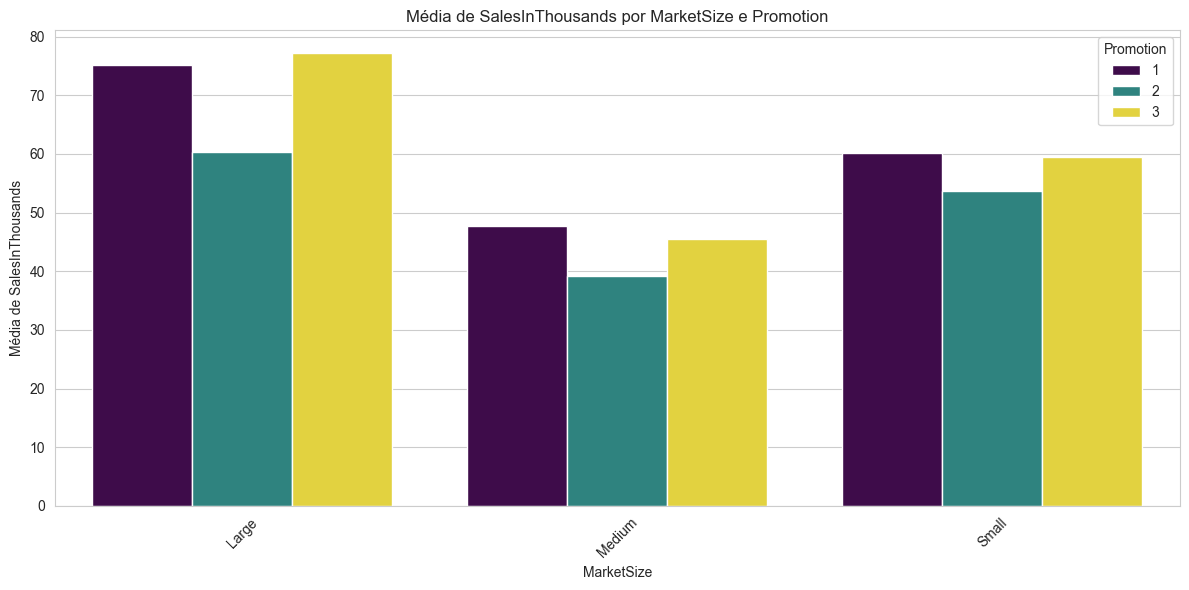

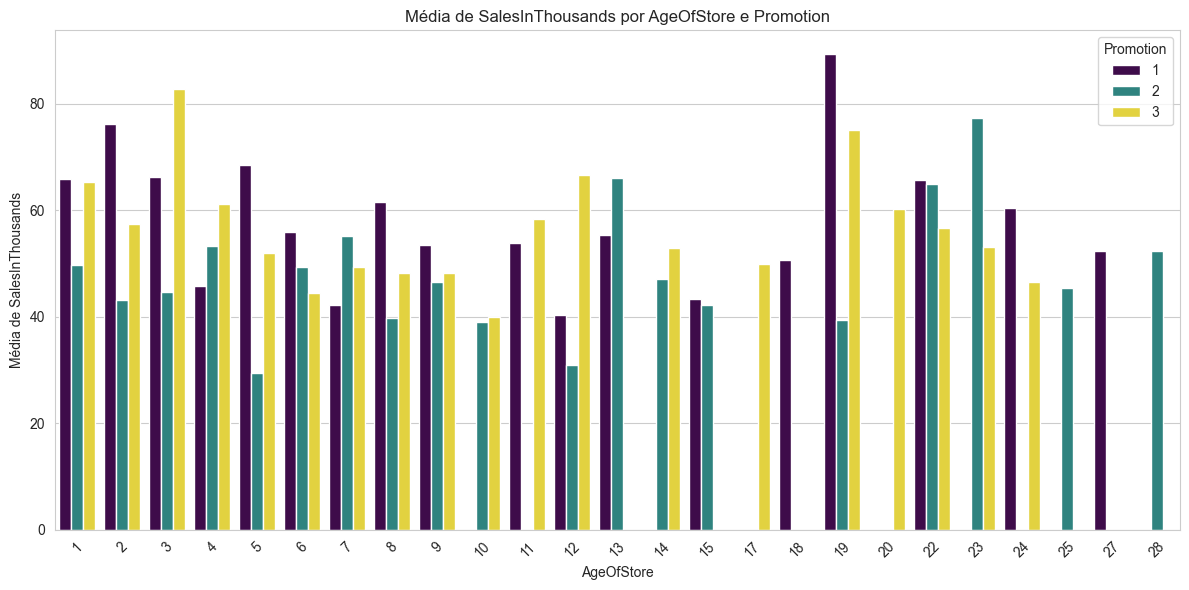

In [12]:
# Visualizações de SalesInThousands agregadas por Promotion, agrupadas por diferentes dimensões

# Lista das dimensões
dimensions = ['week', 'Promotion', 'MarketID', 'LocationID', 'MarketSize', 'AgeOfStore']

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

for dim in dimensions:
    plt.figure(figsize=(12, 6))
    if dim == 'Promotion':
        # Para Promotion, apenas mostrar as médias por promoção
        agg = df.groupby('Promotion')['SalesInThousands'].mean().reset_index()
        sns.barplot(data=agg, x='Promotion', y='SalesInThousands', hue='Promotion', palette='viridis', legend=False)
        plt.title(f'Média de SalesInThousands por Promotion')
    else:
        # Para outras dimensões, agrupar por dimensão e Promotion
        agg = df.groupby([dim, 'Promotion'])['SalesInThousands'].mean().reset_index()
        sns.barplot(data=agg, x=dim, y='SalesInThousands', hue='Promotion', palette='viridis')
        plt.title(f'Média de SalesInThousands por {dim} e Promotion')
        plt.xticks(rotation=45)
    plt.ylabel('Média de SalesInThousands')
    plt.tight_layout()
    plt.show()

Lift de SalesInThousands:
Promotion 2 vs 1: -17.91%
Promotion 3 vs 1: -4.71%


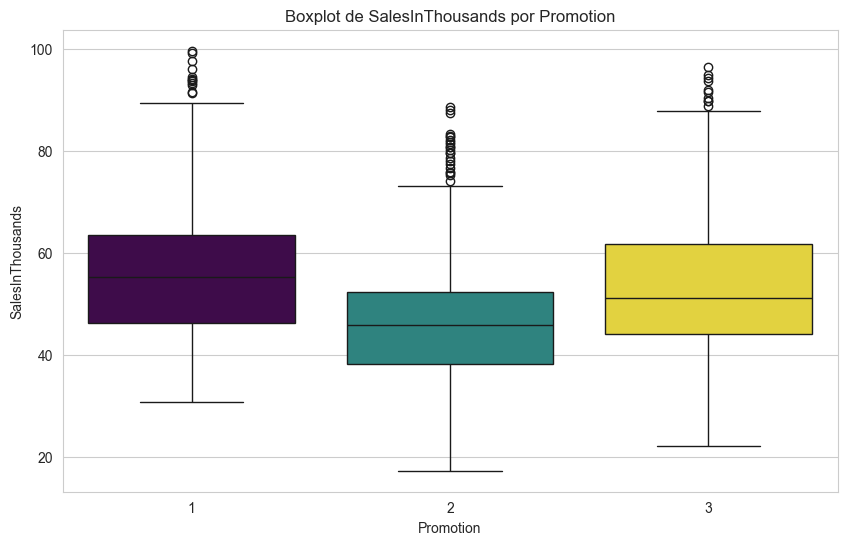

In [13]:
# Cálculo do lift entre promoções
lift_results = calculate_lift(df)
print("Lift de SalesInThousands:")
for key, value in lift_results.items():
    print(f"{key}: {value:.2f}%")

# Boxplots para identificar outliers
plot_sales_boxplots(df)

In [18]:
# Análise da melhor promoção usando ANOVA + Tukey
promotion_analysis = promotion_anova_tukey(df, metric='SalesInThousands', group_col='Promotion')

print("ANOVA para SalesInThousands por Promotion")
print(f"F = {promotion_analysis['anova']['f_stat']:.4f}, p = {promotion_analysis['anova']['p_value']:.4g}")

print("\nMédias de SalesInThousands por Promotion:")
print(promotion_analysis['means'])

best_promo = promotion_analysis['best_promotion']
print(f"\nMelhor promoção por média: Promotion {best_promo}")

if promotion_analysis['anova']['p_value'] < 0.05:
    if promotion_analysis['best_significant_vs_others']:
        print("Esta promoção é significativamente melhor que todas as outras no pós-teste de Tukey (p < 0.05).")
    else:
        print("A promoção com maior média não é significativamente melhor que todas as outras no pós-teste de Tukey.")
else:
    print("A ANOVA não encontrou diferença global significativa entre as promoções (p >= 0.05), então o post-hoc deve ser interpretado com cautela.")

print("\nResultados do teste post-hoc de Tukey:")
print(promotion_analysis['tukey_df'].to_string(index=False))


ANOVA para SalesInThousands por Promotion
F = 20.6156, p = 2.328e-09

Médias de SalesInThousands por Promotion:
Promotion
1    58.099012
3    55.364468
2    47.693668
Name: SalesInThousands, dtype: float64

Melhor promoção por média: Promotion 1
A promoção com maior média não é significativamente melhor que todas as outras no pós-teste de Tukey.

Resultados do teste post-hoc de Tukey:
group1 group2  meandiff  p-adj    lower   upper  reject
     1      2  -10.4053 0.0000 -14.3917 -6.4190    True
     1      3   -2.7345 0.2448  -6.7409  1.2718   False
     2      3    7.6708 0.0000   3.7749 11.5667    True
